In [2]:
from sklearn.datasets import load_digits
import numpy as np

## Exercise 1 (Loading the dataset)

In [3]:
digits = load_digits()
data, target = digits["data"], digits["target"]
data_reduced = data[(target == 3) | (target == 8)]
target_reduced = np.zeros_like(target)
#target_reduced[target == 3] = 1
#target_reduced[target == 8] = -1
target_reduced[target == 3] = 1
target_reduced[target == 8] = -1
target_reduced = target_reduced[target_reduced != 0]
target_reduced[target_reduced == -1] = 0

N_orig, D_orig = data_reduced.shape
data_with_bias = np.zeros((N_orig, D_orig + 1))
data_with_bias[:, :D_orig] = data_reduced
data_with_bias[:, D_orig] = 1

assert data_with_bias.shape[0] == 357, "Ex. States N=357."
assert data_with_bias.shape[1] ==  65, "Ex. States D=65"
#assert np.all((target_reduced == 1) | (target_reduced == -1)), "Ex. States Binary target"

X, y = (data_with_bias - data_with_bias.mean()) / data_with_bias.std(), target_reduced

## Exercise 1.1 (Classification with sklearn)

In [4]:
import sklearn.linear_model
import sklearn.model_selection

In [5]:
grid_search_params = {
  'C': np.arange(1, 15, 0.5)
}
regressor = sklearn.linear_model.LogisticRegression()

# Performs 5-fold-CV by default
grid_search_regressor = sklearn.model_selection.GridSearchCV(regressor, grid_search_params)
grid_search_regressor.fit(X, y);

Going to use best estimator with these params: {'C': 8.5}


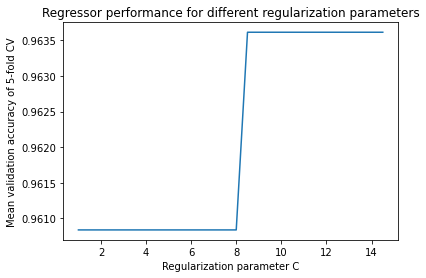

In [6]:
import matplotlib.pyplot as plt

plt.plot(
    grid_search_params['C'],
    grid_search_regressor.cv_results_['mean_test_score']
)
plt.title("Regressor performance for different regularization parameters")
plt.xlabel("Regularization parameter C")
plt.ylabel("Mean validation accuracy of 5-fold CV");
print(f'Going to use best estimator with these params: {grid_search_regressor.best_params_}')

In [7]:
y_pred_baseline = (grid_search_regressor.best_estimator_.predict(X) > 0)[..., np.newaxis]

## Exercise 1.2 Optimization Methods

In [9]:
sigmoid = lambda z: 1.0/(1+np.exp(-z))

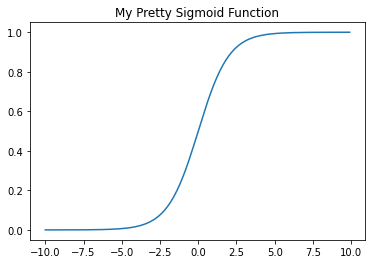

In [24]:
plt.plot(np.arange(-10,10,0.1), sigmoid(np.arange(-10, 10, 0.1)));
plt.title("My Pretty Sigmoid Function");

In [11]:
# import numba

#@numba.jit(forceobj=True)
def gradient_naive(beta, X, y):
    grad = np.zeros((X.shape[1], 1))
    for i in range(X.shape[0]):
        x = X[i, :]
        y_true = y[i]
        pred = sigmoid(np.dot(beta, x))
        for j in range(X.shape[1]):
            grad[j] += np.squeeze((pred - y_true) * x[j])
    return grad
        

In [120]:
beta = np.zeros((1, 3))
Xx = np.array([[3.0, 2.0, 1.0]])
yy = np.array([1.0])
gradient_naive(
  beta, Xx, yy
)

array([[-1.5],
       [-1. ],
       [-0.5]])

In [121]:
gradient = lambda beta, X, y: (sigmoid(X@beta.T).squeeze() - y).T @ X
# TODO Gradient regularization VL 4

In [128]:
predict = lambda beta, X: X@beta.T > 0

In [129]:
zero_one_loss = lambda y, y_pred: np.count_nonzero(((y[:, np.newaxis] > 0) ^ y_pred)) / len(y)

### 1) Gradient descent

In [139]:
# Gradient descent:
# tau = 0.1
# M = 100
X[:, X.shape[1] - 1] = 1

In [140]:
# TODO Regularization.
def optimize_gradient_descent(
  X,
  y,
  lr_init=0.1,
  lr_schedule=lambda lr, epoch: lr,
  epochs=100,
  weight_init_fn=lambda n_feats: np.zeros((1, n_feats))
):
    N, M = X.shape
    beta = weight_init_fn(M)
    lr = lr_init
    for epoch in range(epochs):
        beta = beta - (1/N) * (lr * gradient(beta, X, y).squeeze())
        lr = lr_schedule(lr, epoch + 1)
    return beta

In [141]:
zero_one_loss(
    y, 
    predict(optimize_gradient_descent(X, y), X)
)

0.0056022408963585435

### 2) Stochastic Gradient Descent

In [179]:
def optimize_stochastic_gradient_descent(
  X,
  y,
  batch_size=1,
  lr_init=0.1,
  lr_schedule=lambda lr, epoch: lr / (1 + 0.0001 * epoch),
  epochs=100,
  weight_init_fn=lambda n_feats: np.zeros((1, 65))
):
    N, M = X.shape
    beta = weight_init_fn(M)
    lr = lr_init
    dataloader = list(zip(np.array_split(X, N // batch_size), np.array_split(y, N // batch_size)))
    for epoch in range(epochs):
        for X_batch, y_batch in dataloader:
            beta = beta - (1/N) * (lr * gradient(beta, X, y).squeeze())
        lr = lr_schedule(lr, epoch + 1)
    return beta

In [180]:
zero_one_loss(
    y, 
    predict(optimize_stochastic_gradient_descent(
        X, y, batch_size=4, epochs=1, lr_init=0.5
    ), X)
)

0.0

In [151]:
N = X.shape[0]
batch_size = 2
dataloader = zip(np.array_split(X, N // batch_size), np.array_split(y, N // batch_size))


In [152]:
len(list(dataloader))

178

In [153]:
N

357